In [1]:
!pip install langgraph opencv-python numpy

 **Module C: Adversarial Defense (The "10+ Years" Differentiator)
"Attackers are using Stable Diffusion and GANs to generate fake IDs that look perfect to the human eye. 5 Standard classifiers are failing. How do you build a defense against generative AI attacks?"**

In [1]:
LLM_Text_Extraction
|
Field Validation
|
Forensic Checks
|
Image Layout Validation
|
Risk Scoring
|
Decision(Approve/Reject)

In [ ]:
from google.colab import drive,userdata
drive.mount('/content/drive/')

In [3]:
from typing import TypedDict, Dict, Any
from langgraph.graph import StateGraph, END
import cv2,glob
import numpy as np
from datetime import datetime
import os,base64,json
from openai import OpenAI


# -----------------------------
# 1. Graph State
# -----------------------------
class IDDefenseState(TypedDict):
    image_path: str
    extracted_fields: Dict[str, Any]
    forensic_scores: Dict[str, float]
    field_scores: Dict[str, float]
    layout_scores: Dict[str, float]
    final_risk_score: float
    decision: str
    reason: str




In [4]:
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

In [5]:
# -----------------------------
# 2. Utility functions
# -----------------------------
def load_gray(image_path: str):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Unable to load image: {image_path}")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image, gray

In [6]:
def score_edge_artifacts(gray):
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size
    return min(edge_density * 5, 1.0)

In [7]:
def score_compression_mismatch(gray):
    h, w = gray.shape
    block_stds = []

    for y in range(0, h - 8, 8):
        for x in range(0, w - 8, 8):
            block = gray[y:y + 8, x:x + 8]
            block_stds.append(np.std(block))

    variation = np.std(block_stds)
    return min(variation / 50, 1.0)

In [8]:
def score_noise_inconsistency(gray):
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    noise = cv2.absdiff(gray, blur)

    h, w = noise.shape
    patch_scores = []

    for y in range(0, h - 32, 32):
        for x in range(0, w - 32, 32):
            patch = noise[y:y + 32, x:x + 32]
            patch_scores.append(np.std(patch))

    inconsistency = np.std(patch_scores)
    return min(inconsistency / 25, 1.0)

In [9]:
def score_blur_sharpness(gray):
    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    if lap_var < 50:
        return 0.8      # too blurry
    elif lap_var > 2000:
        return 0.7      # unnaturally sharp
    return 0.2

In [10]:
# -----------------------------
# 3. LangGraph Nodes
# -----------------------------
def image_forensics_node(state: IDDefenseState):
    _, gray = load_gray(state["image_path"])

    forensic_scores = {
        "edge_artifacts": score_edge_artifacts(gray),
        "compression_mismatch": score_compression_mismatch(gray),
        "noise_inconsistency": score_noise_inconsistency(gray),
        "blur_or_oversharp": score_blur_sharpness(gray)
    }

    return {
        "forensic_scores": forensic_scores
    }

In [11]:
# -----------------------------
# 4. field_validation
# -----------------------------
def field_validation_node(state: IDDefenseState):
    fields = state["extracted_fields"]

    nik = str(fields.get("nik", "")).strip()
    full_name = str(fields.get("full_name", "")).strip()
    dob = str(fields.get("dob", "")).strip()
    address = str(fields.get("address", "")).strip()
    nationality = str(fields.get("nationality", "")).strip()

    field_scores = {}

    field_scores["nik_invalid"] = 0.0 if nik.isdigit() and len(nik) == 16 else 1.0
    field_scores["full_name_invalid"] = 0.0 if full_name is None and len(full_name) == 0 else 1.0

    try:
        datetime.strptime(dob, "%Y-%m-%d")
        field_scores["dob_invalid"] = 0.0
    except Exception:
        field_scores["dob_invalid"] = 1.0

    field_scores["address_invalid"] = 0.0 if len(address) >= 5 else 1.0
    field_scores["nationality_invalid"] = 0.0 if nationality.upper() in ["WNI", "WNA"] else 1.0

    return {
        "field_scores": field_scores
    }

In [12]:
# -----------------------------
# 5. Layout validation
# -----------------------------
def layout_validation_node(state: IDDefenseState):
    """
    Baseline placeholder.
    In production, compare detected field bounding boxes against known ID templates.
    """

    fields = state["extracted_fields"]

    required_fields = ["nik", "dob", "full_name","address","nationality"]
    missing_count = sum(1 for field in required_fields if not fields.get(field))

    layout_scores = {
        "missing_required_fields": min(missing_count / len(required_fields), 1.0),
        "template_mismatch": 0.3
    }

    return {
        "layout_scores": layout_scores
    }

In [13]:
# -----------------------------
# 6. Risk Scoring
# -----------------------------
def risk_scoring_node(state: IDDefenseState):
    forensic = state["forensic_scores"]
    field = state["field_scores"]
    layout = state["layout_scores"]

    score = (
        forensic["edge_artifacts"] * 0.15 +
        forensic["compression_mismatch"] * 0.10 +
        forensic["noise_inconsistency"] * 0.10 +
        forensic["blur_or_oversharp"] * 0.10 +
        field["nik_invalid"] * 0.25 +
        field["full_name_invalid"] * 0.15 +
        field["dob_invalid"] * 0.05 +
        field["address_invalid"] * 0.03 +
        field["nationality_invalid"] * 0.02 +
        layout["missing_required_fields"] * 0.03 +
        layout["template_mismatch"] * 0.02
    )

    return {
        "final_risk_score": round(score, 3)
    }

In [14]:
# -----------------------------
# 6. Decision as Approve/Manual Review or Reject
# -----------------------------
def decision_node(state: IDDefenseState):
    risk = state["final_risk_score"]

    if risk < 0.30:
        decision = "APPROVE"
        reason = "Low synthetic/tampering risk."
    elif risk < 0.70:
        decision = "MANUAL_REVIEW"
        reason = "Medium risk. Send to human verification."
    else:
        decision = "REJECT"
        reason = "High risk of AI-generated or tampered ID."

    return {
        "decision": decision,
        "reason": reason
    }

In [15]:
def image_to_base64_data_url(image_path: str) -> str:
    ext = image_path.lower().split(".")[-1]

    mime_map = {
        "jpg": "image/jpeg",
        "jpeg": "image/jpeg",
        "png": "image/png",
        "webp": "image/webp"
    }

    mime_type = mime_map.get(ext, "image/jpeg")

    with open(image_path, "rb") as f:
        encoded = base64.b64encode(f.read()).decode("utf-8")

    return f"data:{mime_type};base64,{encoded}"

In [16]:
# -----------------------------
# 7. Extract the Fields using the LLM
# -----------------------------
def llm_extract_id_fields(image_path: str) -> Dict[str, Any]:
    image_data_url = image_to_base64_data_url(image_path)

    prompt = """
You are extracting fields from an Indonesian KTP card.

Return ONLY valid JSON.
Do not hallucinate.
If a value is not clearly visible, return null.

Extract ONLY:
- id_number
- full_name
- date_of_birth
- address
- nationality
- expiry_date

Rules:
1. id_number must come from NIK or any 16 digits number in the Id card.
2. full_name must come from Nama.
3. date_of_birth must come from Tempat/Tgl Lahir, it follow DD-MM-YYYY.
4. address must come from Alamat.
5. nationality must come from Kewarganegaraan.
6. expiry_date must come from Berlaku Hingga.
7. date_of_birth must be YYYY-MM-DD.
8. Do not include extra fields.
9. Do not wrap JSON inside markdown.
10.Do not return ```json.

Return STRICT JSON only with this schema and must not return extra strings:
{
  "nik": string or null,
  "full_name": string or null,
  "dob": string or null,
  "address": string or null,
  "nationality": string or null,
  "expiry_date": string or null
}
"""

    response = client.responses.create(
        model="gpt-4.1-mini",
        temperature =0,
        top_p = 1,
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": prompt},
                    {
                        "type": "input_image",
                        "image_url": image_data_url
                    }
                ]
            }
        ]
    )

    text = response.output_text.strip()

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {
            "nik": None,
            "full_name": None,
            "dob": None,
            "address": None,
            "nationality": None,
            "expiry_date": None,
            "raw_llm_output": text
        }

In [17]:
def llm_extraction_node(state: IDDefenseState):
    fields = llm_extract_id_fields(state["image_path"])
    return {"extracted_fields": fields}

In [18]:
# -----------------------------
# 8. Workflow Orchestration
# -----------------------------
def build_id_defense_graph():
    graph = StateGraph(IDDefenseState)

    graph.add_node("llm_extraction", llm_extraction_node)
    graph.add_node("image_forensics", image_forensics_node)
    graph.add_node("field_validation", field_validation_node)
    graph.add_node("layout_validation", layout_validation_node)
    graph.add_node("risk_scoring", risk_scoring_node)
    graph.add_node("decision", decision_node)

    graph.set_entry_point("llm_extraction")

    graph.add_edge("llm_extraction", "image_forensics")
    graph.add_edge("image_forensics", "field_validation")
    graph.add_edge("field_validation", "layout_validation")
    graph.add_edge("layout_validation", "risk_scoring")
    graph.add_edge("risk_scoring", "decision")
    graph.add_edge("decision", END)

    return graph.compile()

**9. Sample Run for 1 image:**

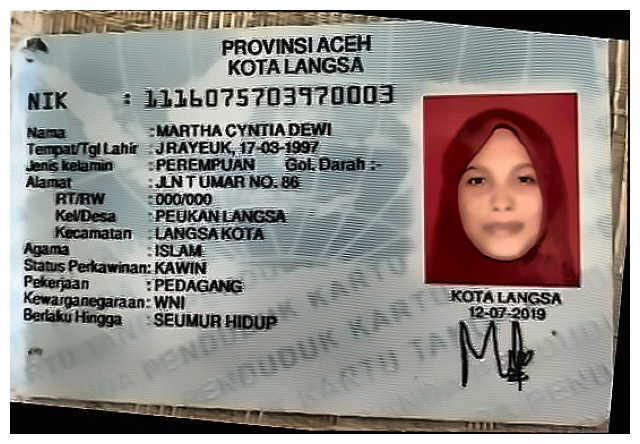

In [19]:
import matplotlib.pyplot as plt

image_path = "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/7d2602fb-ktp-200_jpg.rf.6856d27f5864e6a907e9013143df0386.jpg"

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [20]:


app = build_id_defense_graph()

input_state = {
    "image_path": "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/7d2602fb-ktp-200_jpg.rf.6856d27f5864e6a907e9013143df0386.jpg",
    "extracted_fields": {},
    "forensic_scores": {},
    "field_scores": {},
    "layout_scores": {},
    "final_risk_score": 0.0,
    "decision": "",
    "reason": ""
}

result = app.invoke(input_state)

print(result["extracted_fields"])
print(result["final_risk_score"])
print(result["decision"])
print(result["reason"])

{'nik': '1111075703970003', 'full_name': 'MARTHA CYNTHIA DEWI', 'dob': '1997-03-17', 'address': 'JLN T UMAR NO: 86', 'nationality': 'WNI', 'expiry_date': 'SEUMUR HIDUP'}
0.429
MANUAL_REVIEW
Medium risk. Send to human verification.


In [21]:
app = build_id_defense_graph()

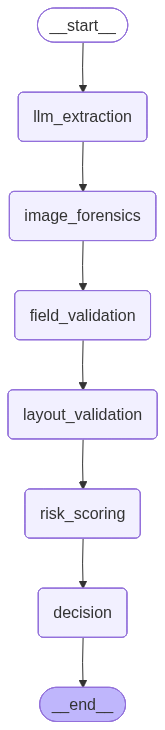

In [22]:
app

**10. Run for bulk images in Google Drive**

In [23]:
folder_path = "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/"
output_folder = "/content/drive/My Drive/kyc_train/after_preprocess_image/LLM_Extracted_Image_Approval/"

image_paths = (
    glob.glob(folder_path + "*.jpg") +
    glob.glob(folder_path + "*.jpeg") +
    glob.glob(folder_path + "*.png")
)

results = []

for image_path in image_paths:
    input_state["image_path"] = image_path

    result = app.invoke(input_state)

    results.append({
        "image_path": image_path,
        "risk_score": result["final_risk_score"],
        "decision": result["decision"],
        "reason": result["reason"],
        "forensic_scores": result["forensic_scores"],
        "extracted_fields" : result["extracted_fields"],
        "field_scores": result["field_scores"],
        "layout_scores": result["layout_scores"]
    })

In [24]:
import pandas as pd

df = pd.DataFrame(results)

csv_path = os.path.join(output_folder, "ktp_approve_reject_results.csv")

df.to_csv(csv_path, index=False)

print("CSV saved:", csv_path)


CSV saved: /content/drive/My Drive/kyc_train/after_preprocess_image/LLM_Extracted_Image_Approval/ktp_approve_reject_results.csv


In [25]:
pd.set_option('display.max_colwidth', None)

In [26]:
df.head(5)

,image_path,risk_score,decision,reason,forensic_scores,extracted_fields,field_scores,layout_scores
0,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/ab391159-ktp-16_jpg.rf.7f3da75ff655703144a959d241c2f881.jpg,0.466,MANUAL_REVIEW,Medium risk. Send to human verification.,"{'edge_artifacts': 0.8848439314254491, 'compression_mismatch': 0.612752284659817, 'noise_inconsistency': 0.45551748284571325, 'blur_or_oversharp': 0.7}","{'nik': '1112000402610002', 'full_name': 'DARMI', 'dob': '1961-02-04', 'address': 'DESA BARU', 'nationality': 'WNI', 'expiry_date': '2018-02-04'}","{'nik_invalid': 0.0, 'full_name_invalid': 1.0, 'dob_invalid': 0.0, 'address_invalid': 0.0, 'nationality_invalid': 0.0}","{'missing_required_fields': 0.0, 'template_mismatch': 0.3}"
1,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/14a928ad-ktp-29_jpg.rf.e74bad0309b246f3bb44c252cb3f15a5.jpg,0.421,MANUAL_REVIEW,Medium risk. Send to human verification.,"{'edge_artifacts': 0.7583478332919048, 'compression_mismatch': 0.5287995824190426, 'noise_inconsistency': 0.28490788945582557, 'blur_or_oversharp': 0.7}","{'nik': '3574035008900003', 'full_name': 'RIZKI FIRMANANDA', 'dob': '1990-08-10', 'address': 'JL SERMA ABD RAHMAN 002/004', 'nationality': 'WNI', 'expiry_date': '2017-08-10'}","{'nik_invalid': 0.0, 'full_name_invalid': 1.0, 'dob_invalid': 0.0, 'address_invalid': 0.0, 'nationality_invalid': 0.0}","{'missing_required_fields': 0.0, 'template_mismatch': 0.3}"
2,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/122abf84-ktp-69_jpg.rf.caa987f30eabcff2bd39f0651ee52ab0.jpg,0.455,MANUAL_REVIEW,Medium risk. Send to human verification.,"{'edge_artifacts': 0.7697685257107347, 'compression_mismatch': 0.6849616474601187, 'noise_inconsistency': 0.4514278402887239, 'blur_or_oversharp': 0.7}","{'nik': '2471014303010002', 'full_name': 'MURNIATI AWALIA', 'dob': '2001-03-03', 'address': 'JL H SUPIYU YUSUF RT/RW 002/001', 'nationality': 'WNI', 'expiry_date': 'SEUMUR HIDUP'}","{'nik_invalid': 0.0, 'full_name_invalid': 1.0, 'dob_invalid': 0.0, 'address_invalid': 0.0, 'nationality_invalid': 0.0}","{'missing_required_fields': 0.0, 'template_mismatch': 0.3}"
3,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/7d2602fb-ktp-200_jpg.rf.6856d27f5864e6a907e9013143df0386.jpg,0.429,MANUAL_REVIEW,Medium risk. Send to human verification.,"{'edge_artifacts': 0.7460583941605838, 'compression_mismatch': 0.5746882773851435, 'noise_inconsistency': 0.33227657329418625, 'blur_or_oversharp': 0.7}","{'nik': '1111075703970003', 'full_name': 'MARTHA CYNTHIA DEWI', 'dob': '1997-03-17', 'address': 'JLN T UMAR NO 86', 'nationality': 'WNI', 'expiry_date': 'SEUMUR HIDUP'}","{'nik_invalid': 0.0, 'full_name_invalid': 1.0, 'dob_invalid': 0.0, 'address_invalid': 0.0, 'nationality_invalid': 0.0}","{'missing_required_fields': 0.0, 'template_mismatch': 0.3}"
4,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/6a2ad321-IMG_20220519_165451_jpg.rf.a111486b9a69d6a3bf13ff0d566fcf9a.jpg,0.372,MANUAL_REVIEW,Medium risk. Send to human verification.,"{'edge_artifacts': 0.43510758159172686, 'compression_mismatch': 0.505723124075136, 'noise_inconsistency': 0.30134741440393903, 'blur_or_oversharp': 0.7}","{'nik': '3273110407880003', 'full_name': 'HERI IRAWAN', 'dob': '1988-07-04', 'address': 'SUMEDANG', 'nationality': 'WNI', 'expiry_date': '2020-10-19'}","{'nik_invalid': 0.0, 'full_name_invalid': 1.0, 'dob_invalid': 0.0, 'address_invalid': 0.0, 'nationality_invalid': 0.0}","{'missing_required_fields': 0.0, 'template_mismatch': 0.3}"


In [29]:
df['decision'].value_counts()

,count
decision,
MANUAL_REVIEW,129
APPROVE,67
REJECT,5


**Analyzing the Rejected Items:**

In [30]:
df[df['decision'] == 'REJECT']

,image_path,risk_score,decision,reason,forensic_scores,extracted_fields,field_scores,layout_scores
35,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/4fe73e09-ktp-17_jpg.rf.2fcbc766e50f8c7f369a85adb5e819f2.jpg,0.730,REJECT,High risk of AI-generated or tampered ID.,"{'edge_artifacts': 0.8433203270159793, 'compression_mismatch': 0.6509633966881573, 'noise_inconsistency': 0.3008019254330665, 'blur_or_oversharp': 0.7}","{'nik': None, 'full_name': 'SAKIDI', 'dob': '1962-05-04', 'address': 'GONDANG TENGAH 002 / 004 PURWOSARI WONOGIRI', 'nationality': None, 'expiry_date': None}","{'nik_invalid': 1.0, 'full_name_invalid': 1.0, 'dob_invalid': 0.0, 'address_invalid': 0.0, 'nationality_invalid': 1.0}","{'missing_required_fields': 0.4, 'template_mismatch': 0.3}"
168,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/5c162e23-ktp-49_jpg.rf.02ad55dd102d63027cfb36e90c60e1a1.jpg,0.718,REJECT,High risk of AI-generated or tampered ID.,"{'edge_artifacts': 0.9741660065135112, 'compression_mismatch': 0.5925813368391109, 'noise_inconsistency': 0.3629524245425441, 'blur_or_oversharp': 0.7}","{'nik': '31730117078300027', 'full_name': 'JEKY ARGANA', 'dob': '1983-07-17', 'address': 'KAYU BESAR NO. 12', 'nationality': 'WNI', 'expiry_date': 'SEUMUR HIDUP'}","{'nik_invalid': 1.0, 'full_name_invalid': 1.0, 'dob_invalid': 0.0, 'address_invalid': 0.0, 'nationality_invalid': 0.0}","{'missing_required_fields': 0.0, 'template_mismatch': 0.3}"
181,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/4fe73e09-ktp-17_jpg.rf.3819fbf415ea06960975da0bcc97ae3e.jpg,0.713,REJECT,High risk of AI-generated or tampered ID.,"{'edge_artifacts': 0.7260698198198199, 'compression_mismatch': 0.5927084680962744, 'noise_inconsistency': 0.365866236079208, 'blur_or_oversharp': 0.7}","{'nik': None, 'full_name': 'SAKIDI', 'dob': '1962-05-04', 'address': 'GONDANG TENGAH', 'nationality': None, 'expiry_date': None}","{'nik_invalid': 1.0, 'full_name_invalid': 1.0, 'dob_invalid': 0.0, 'address_invalid': 0.0, 'nationality_invalid': 1.0}","{'missing_required_fields': 0.4, 'template_mismatch': 0.3}"
186,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/9f5eda22-ktp-48_jpg.rf.847fb14c818e1254f8eb6653b085d0af.jpg,0.736,REJECT,High risk of AI-generated or tampered ID.,"{'edge_artifacts': 1.0, 'compression_mismatch': 0.5919960581598128, 'noise_inconsistency': 0.3914012374413007, 'blur_or_oversharp': 0.7}","{'nik': None, 'full_name': None, 'dob': '2004-06-29', 'address': 'JL. DANAU LEMPANG NO 15 A', 'nationality': 'WNI', 'expiry_date': 'SEUMUR HIDUP'}","{'nik_invalid': 1.0, 'full_name_invalid': 1.0, 'dob_invalid': 0.0, 'address_invalid': 0.0, 'nationality_invalid': 0.0}","{'missing_required_fields': 0.4, 'template_mismatch': 0.3}"
197,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/4affbc3d-ktp-51_jpg.rf.776aae5096657885ebc42d71159aa2bd.jpg,0.732,REJECT,High risk of AI-generated or tampered ID.,"{'edge_artifacts': 1.0, 'compression_mismatch': 0.6283974497896859, 'noise_inconsistency': 0.4329886933000144, 'blur_or_oversharp': 0.7}","{'nik': '73120130081995002', 'full_name': 'MUHAMMAD NASRUL', 'dob': '1995-08-30', 'address': 'LAPAJUNG', 'nationality': 'WNI', 'expiry_date': 'SEUMUR HIDUP'}","{'nik_invalid': 1.0, 'full_name_invalid': 1.0, 'dob_invalid': 0.0, 'address_invalid': 0.0, 'nationality_invalid': 0.0}","{'missing_required_fields': 0.0, 'template_mismatch': 0.3}"


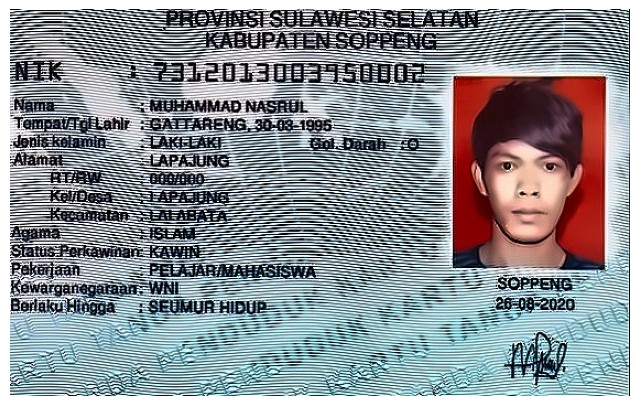

In [31]:
import matplotlib.pyplot as plt

image_path = "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/4affbc3d-ktp-51_jpg.rf.776aae5096657885ebc42d71159aa2bd.jpg"

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()